## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>


## <span style="color:black;"><strong>Datos de los estudiantes</strong></span>

In [ ]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

📝 Ingresa tu nombre completo: David Felipe Tovar Zurita - Jhon Alejandro Garcia Pareja
📧 Ingresa tu correo electrónico: david.tovarz@udea.edu.co - Jhonalejandrogarciapareja@gmail.com
🔢 Ingresa los últimos 6 dígitos de tu cédula: 970113 - 442407


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

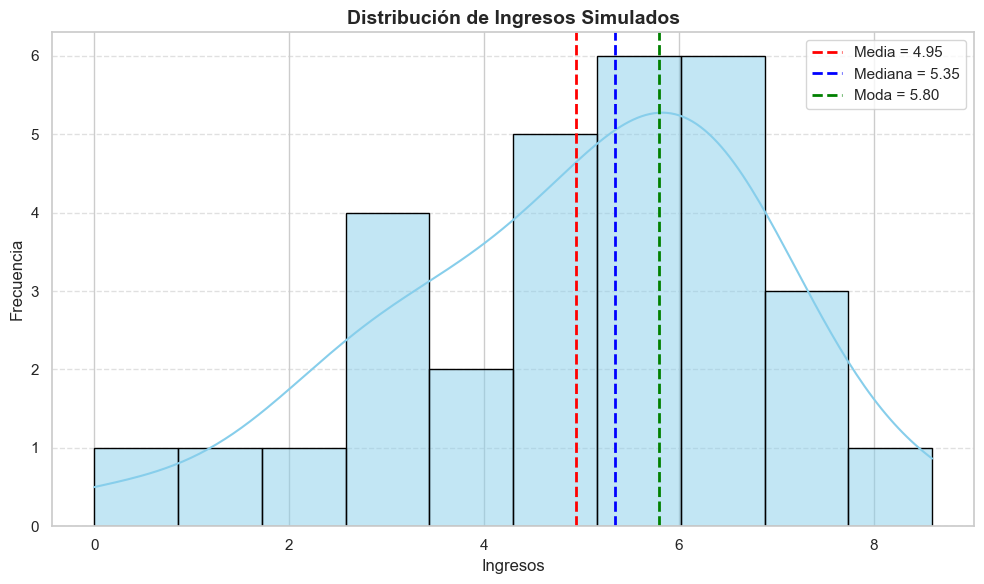

       MEDIDAS DE TENDENCIA CENTRAL

  Base (últimos 6 dígitos):  442407
  Media teórica:             9 millones COP
  Desviación estándar:       2
  Tamaño de muestra:         30

  Media   (promedio):        8.7713 millones COP
  Mediana (valor central):   8.7529 millones COP
  Moda    (más frecuente):   7.0296 millones COP
                                                    


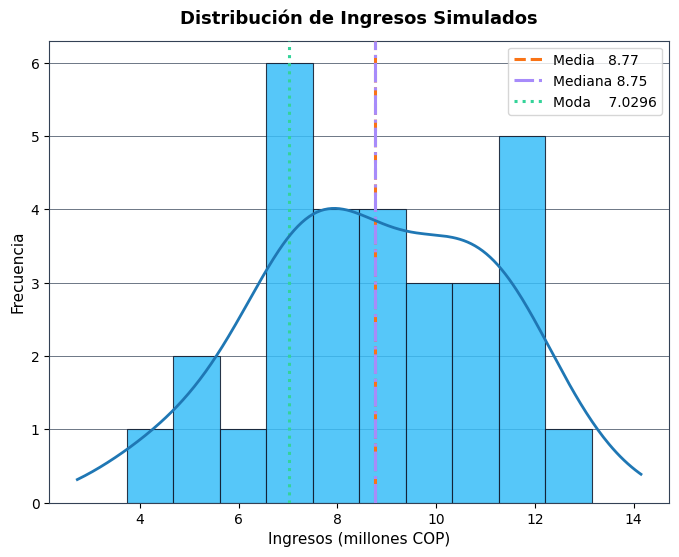

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

base = 442407
np.random.seed(base)

media_teorica = (base % 10) + 2
desv_est      = 2
n             = 30

#Simulacion
ingresos_raw = np.random.normal(loc=media_teorica, scale=desv_est, size=n)
ingresos     = np.where(ingresos_raw < 0, 0, ingresos_raw)   # sin negativos

# Medidas de tendencia central
media   = np.mean(ingresos)
mediana = np.median(ingresos)
counts, bin_edges = np.histogram(ingresos, bins=10)
bin_idx_max       = np.argmax(counts)
moda              = (bin_edges[bin_idx_max] + bin_edges[bin_idx_max + 1]) / 2

print("       MEDIDAS DE TENDENCIA CENTRAL")
print("")
print(f"  Base (últimos 6 dígitos):  {base}")
print(f"  Media teórica:             {media_teorica} millones COP")
print(f"  Desviación estándar:       {desv_est}")
print(f"  Tamaño de muestra:         {n}")
print("")
print(f"  Media   (promedio):        {media:.4f} millones COP")
print(f"  Mediana (valor central):   {mediana:.4f} millones COP")
print(f"  Moda    (más frecuente):   {moda:.4f} millones COP")
print(" " * 52)


COLOR_CARD = "#1e293b"
COLOR_BAR  = "#38bdf8"
COLOR_MEAN = "#f97316"
COLOR_MED  = "#a78bfa"
COLOR_MOD  = "#34d399"

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
for spine in ax1.spines.values():
    spine.set_edgecolor("#334155")

# Histograma
counts, bin_edges, _ = ax1.hist(ingresos, bins=10, color=COLOR_BAR, edgecolor="#0f172a",
                                 linewidth=0.8, alpha=0.85, zorder=2)

kde        = stats.gaussian_kde(ingresos)
x_kde      = np.linspace(ingresos.min() - 1, ingresos.max() + 1, 300)
bin_width  = bin_edges[1] - bin_edges[0]
ax1.plot(x_kde, kde(x_kde) * n * bin_width,
         linewidth=2, linestyle="-", zorder=4)

ax1.axvline(media,   color=COLOR_MEAN, linewidth=2.2, linestyle="--", label=f"Media   {media:.2f}", zorder=3)
ax1.axvline(mediana, color=COLOR_MED,  linewidth=2.2, linestyle="-.", label=f"Mediana {mediana:.2f}", zorder=3)
ax1.axvline(moda,    color=COLOR_MOD,  linewidth=2.2, linestyle=":",  label=f"Moda    {moda:.4f}", zorder=3)

ax1.set_title("Distribución de Ingresos Simulados", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Ingresos (millones COP)", fontsize=11)
ax1.set_ylabel("Frecuencia", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(axis="y", color="#334155", linewidth=0.5, zorder=1)

plt.show()

<h3><b>Interpretaciones</b></h3>

<ul>
  <li>La media está muy cerca de la media teórica de 9 millones; la diferencia de 0.23 M es natural por la variabilidad aleatoria de una muestra pequeña con n=30.</li>
</ul>

<ul>
  <li>La mediana nos indica que el 50% de las personas gana menos de 8.75 millones y el otro 50% gana más.</li>
    Su cercanía con la media (diferencia de solo 0.02 M, practicamente iguales) indica que la distribución es simétrica y sin valores extremos dominantes.
</ul>

<ul>
  <li>La moda corresponde al intervalo más frecuente(la barra más alta del histograma).</li>
    Es menor que la media porque los valores altos del lado derecho (12–14 M) jalan el promedio hacia la derecha.
</ul>


### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

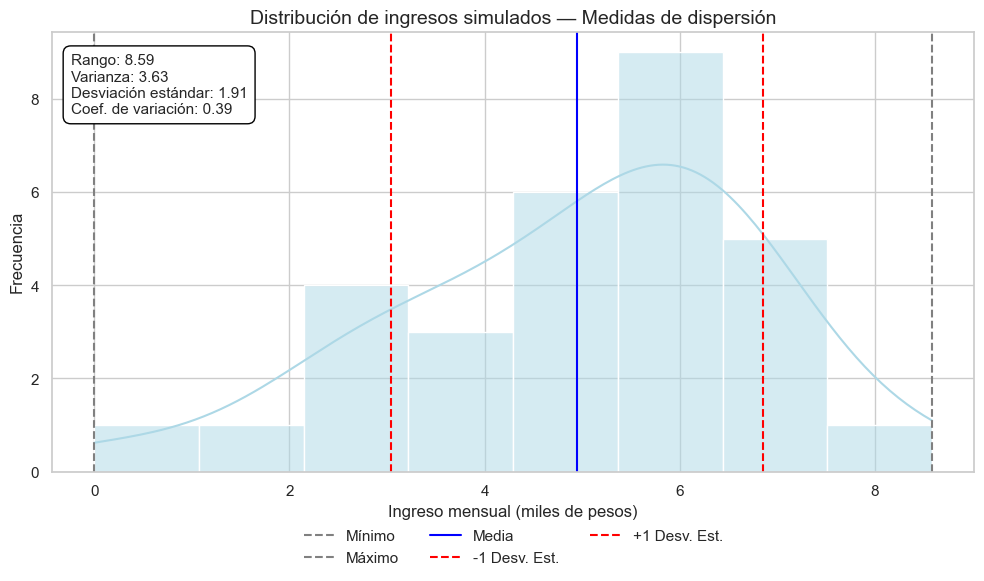

       MEDIDAS DE DISPERSIÓN

  Base (últimos 6 dígitos):  442407
  Media teórica:             9 millones COP
  Tamaño de muestra:         30

  Rango:                     9.4119 millones COP
  Varianza muestral:         5.3358
  Desviación estándar:       2.3099 millones COP
  Coeficiente de variación:  26.34 %
                                                    


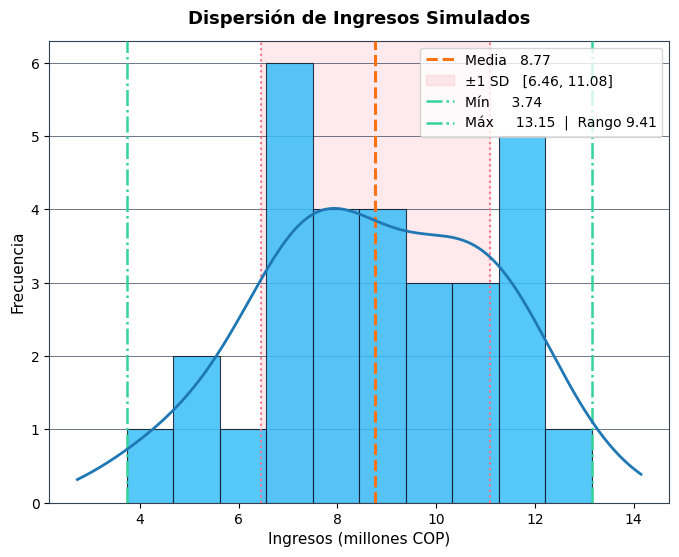

In [ ]:
#Cálculos
rango    = np.max(ingresos) - np.min(ingresos)
varianza = np.var(ingresos, ddof=1)       # ddof=1 → varianza muestral
desv_std = np.std(ingresos, ddof=1)       # desviación estándar muestral
cv       = (desv_std / media) * 100       # coeficiente de variación en %

print("       MEDIDAS DE DISPERSIÓN")
print("")
print(f"  Base (últimos 6 dígitos):  {base}")
print(f"  Media teórica:             {media_teorica} millones COP")
print(f"  Tamaño de muestra:         {n}")
print("")
print(f"  Rango:                     {rango:.4f} millones COP")
print(f"  Varianza muestral:         {varianza:.4f}")
print(f"  Desviación estándar:       {desv_std:.4f} millones COP")
print(f"  Coeficiente de variación:  {cv:.2f} %")
print(" " * 52)

# Gráfica
COLOR_BAR  = "#38bdf8"
COLOR_MEAN = "#f97316"
COLOR_STD  = "#fb7185"
COLOR_RNG  = "#34d399"

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_edgecolor("#334155")

# Histograma base
counts_h, bin_edges_h, _ = ax.hist(
    ingresos, bins=10, color=COLOR_BAR, edgecolor="#0f172a",
    linewidth=0.8, alpha=0.85, zorder=2
)

kde       = stats.gaussian_kde(ingresos)
x_kde     = np.linspace(ingresos.min() - 1, ingresos.max() + 1, 300)
bin_width = bin_edges_h[1] - bin_edges_h[0]
ax.plot(x_kde, kde(x_kde) * n * bin_width, linewidth=2, linestyle="-", zorder=4)

# Media
ax.axvline(media, color=COLOR_MEAN, linewidth=2.2, linestyle="--",
           label=f"Media   {media:.2f}", zorder=3)

ax.axvspan(media - desv_std, media + desv_std,
           alpha=0.15, color=COLOR_STD, zorder=1,
           label=f"±1 SD   [{media - desv_std:.2f}, {media + desv_std:.2f}]")
ax.axvline(media - desv_std, color=COLOR_STD, linewidth=1.5, linestyle=":", zorder=3)
ax.axvline(media + desv_std, color=COLOR_STD, linewidth=1.5, linestyle=":", zorder=3)

# Rango (mín y máx)
ax.axvline(ingresos.min(), color=COLOR_RNG, linewidth=1.8, linestyle="-.",
           label=f"Mín     {ingresos.min():.2f}", zorder=3)
ax.axvline(ingresos.max(), color=COLOR_RNG, linewidth=1.8, linestyle="-.",
           label=f"Máx     {ingresos.max():.2f}  |  Rango {rango:.2f}", zorder=3)

ax.set_title("Dispersión de Ingresos Simulados", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Ingresos (millones COP)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", color="#334155", linewidth=0.5, zorder=1)

plt.show()

###**Interpretaciones**

<text>1. Rango</text>

Existe una diferencia de 9.41 millones entre ambos extremos, lo que indica que hay cierta variabilidad en los ingresos simulados.
Tiene una limitación y es que solo usa dos valores (mínimo y máximo), por lo que un solo dato extremo puede distorsionarlo.

<text>2. Varianza</text>

Al estar en unidades al cuadrado (millones²), es difícil interpretarla directamente, por eso se complementa con la desviación estándar.
Un valor de 5.34 indica una dispersión moderada alrededor de la media de 8.77 M.

<text>3. Desviación Estándar</text>

En promedio, cada ingreso se aleja 2.31 millones de la media (8.77 M).
La banda rosada de la gráfica muestra que el intervalo ±1 SD = [6.46, 11.08] captura la mayoría de los datos, lo cual es coherente con una distribución aproximadamente normal.
Tiene una diferencia muy pequeña con la desviación teórica usada para simular (2), diferencia esperada por aleatoriedad muestral.

<text>4. Coeficiente de Variación </text>

Por cada 100 pesos de ingreso promedio, la dispersión es de 26.34 pesos.
Al ser menor al 30%, se interpreta como una dispersión relativamente baja, los ingresos no están muy dispersos respecto a su media.

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

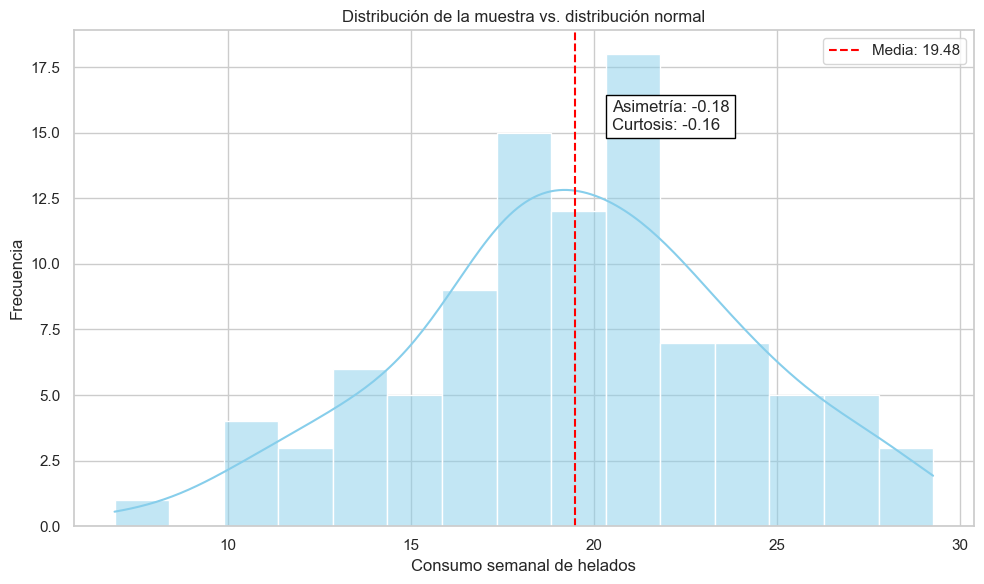


       ASIMETRÍA Y CURTOSIS

  Base (últimos 6 dígitos):  442407
  Tamaño de muestra:         30

  Asimetría (skew):          -0.1608  →  aproximadamente simétrica
  Curtosis  (excess):        -0.6785  →  mesocúrtica (similar a normal)
                                                    


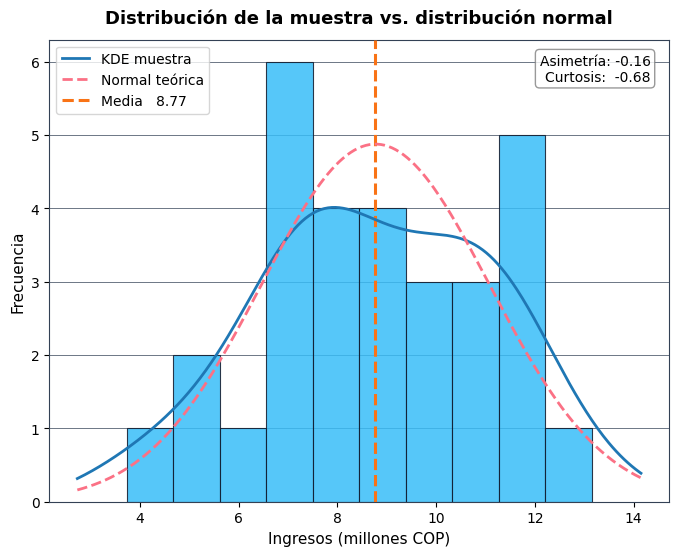

In [ ]:

from scipy.stats import norm

#Cálculos
skew     = stats.skew(ingresos)
curtosis = stats.kurtosis(ingresos)

if skew > 0.5:
    tipo_asim = "positiva (cola derecha)"
elif skew < -0.5:
    tipo_asim = "negativa (cola izquierda)"
else:
    tipo_asim = "aproximadamente simétrica"

if curtosis > 1:
    tipo_kurt = "leptocúrtica (pico pronunciado)"
elif curtosis < -1:
    tipo_kurt = "platicúrtica (achatada)"
else:
    tipo_kurt = "mesocúrtica (similar a normal)"

print("       ASIMETRÍA Y CURTOSIS")
print("")
print(f"  Base (últimos 6 dígitos):  {base}")
print(f"  Tamaño de muestra:         {n}")
print("")
print(f"  Asimetría (skew):          {skew:.4f}  →  {tipo_asim}")
print(f"  Curtosis  (excess):        {curtosis:.4f}  →  {tipo_kurt}")
print(" " * 52)

COLOR_BAR    = "#38bdf8"
COLOR_MEAN   = "#f97316"
COLOR_NORMAL = "#fb7185"   # curva normal teórica

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_edgecolor("#334155")

# Histograma
counts_h, bin_edges_h, _ = ax.hist(
    ingresos, bins=10, color=COLOR_BAR, edgecolor="#0f172a",
    linewidth=0.8, alpha=0.85, zorder=2
)
bin_width = bin_edges_h[1] - bin_edges_h[0]

x_range = np.linspace(ingresos.min() - 1, ingresos.max() + 1, 300)

# KDE de la muestra
kde = stats.gaussian_kde(ingresos)
ax.plot(x_range, kde(x_range) * n * bin_width,
       linewidth=2, linestyle="-",
        zorder=4, label="KDE muestra")

# Curva normal teórica (con media y SD de la muestra)
normal_curve = norm.pdf(x_range, loc=media, scale=desv_std)
ax.plot(x_range, normal_curve * n * bin_width,
        color=COLOR_NORMAL, linewidth=2, linestyle="--",
        zorder=4, label="Normal teórica")

# Media
ax.axvline(media, color=COLOR_MEAN, linewidth=2.2, linestyle="--",
           label=f"Media   {media:.2f}", zorder=3)

# Caja de texto con asimetría y curtosis
textstr = f"Asimetría: {skew:.2f}\nCurtosis:  {curtosis:.2f}"
ax.text(0.97, 0.97, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8),
        color='black')

ax.set_title("Distribución de la muestra vs. distribución normal",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Ingresos (millones COP)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", color="#334155", linewidth=0.5, zorder=1)

plt.show()

<h3><b>Interpretaciones</b></h3>
<h4 style="color:#38bdf8">1. Asimetría (Skew) = −0.16</h4>
<ul>
  <li>El valor es muy cercano a 0, por lo que la distribución es aproximadamente simétrica. El sesgo no es estadisticamente relevante</li>
  <li>El signo negativo leve indica una cola mínima hacia la izquierda, visible en las barras aisladas alrededor de 3–4 millones (valores negativos reemplazados por cero).</li>

</ul>

<h4 style="color:#fb7185">2. Curtosis (excess) = −0.68</h4>
<ul>
  <li>Su valor negativo sugiera una distribución platicúrtica: más achatada y con colas más cortas que una normal estándar.</li>
  <li>Indica que los datos están más dispersos y uniformes alrededor de la media, sin una concentración excesiva en el centro.</li>
  <li>Esto se confirma visualmente: la curva KDE (azul) es más ancha y suave que la curva normal teórica (rosada).</li>
</ul>

<h4 style="color:#f97316">3. Comparación con la distribución normal teórica</h4>
<ul>
  <li>La curva rosada punteada representa cómo se vería una normal perfecta con la misma media (8.77) y desviación estándar (2.31).</li>
  <li>La curva azul (KDE) sigue de cerca a la normal teórica, confirmando que la muestra se comporta de manera aproximadamente normal.</li>
  <li>La principal diferencia es que la KDE tiene un pico más bajo y colas más largas que la normal teórica, consistente con la curtosis negativa.</li>
  <li>La normal teórica es más puntiaguda en el centro, mientras que la muestra real distribuye sus datos de forma más uniforme a lo largo del rango.</li>
</ul>

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

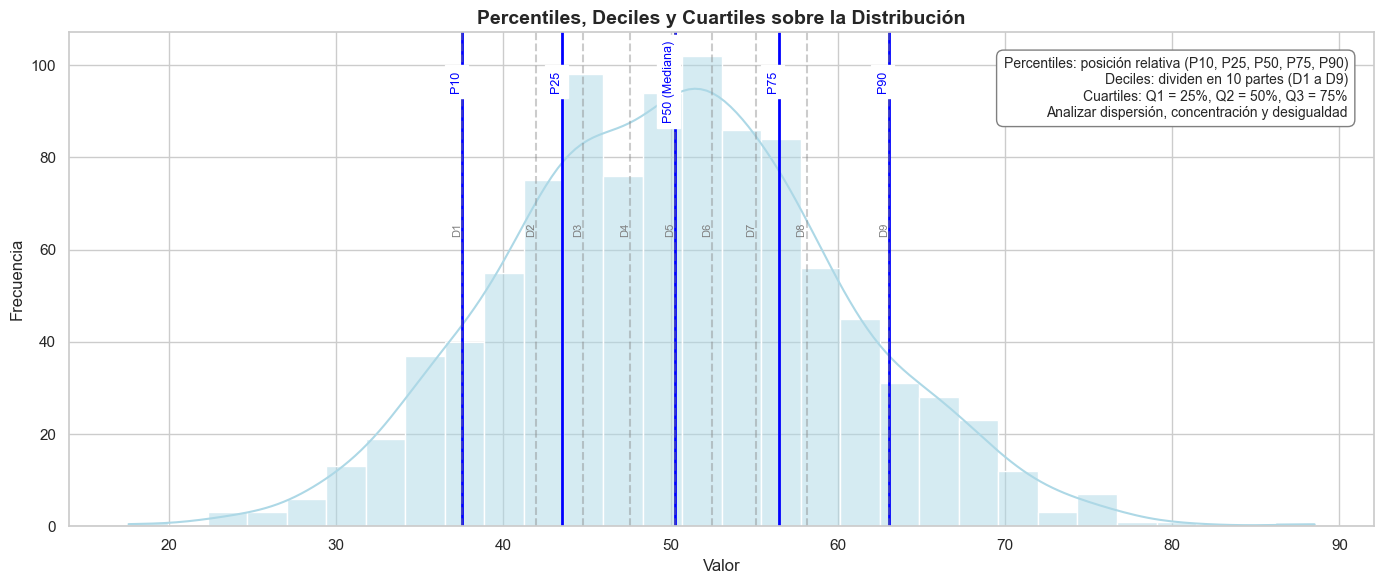

       PERCENTILES, DECILES Y CUARTILES

  Base (últimos 6 dígitos):  442407
  Tamaño de muestra:         30

  PERCENTILES
    P10:   5.7894 millones COP
    P25:   7.1702 millones COP
    P50:   8.7529 millones COP
    P75:   10.6231 millones COP
    P90:   11.5179 millones COP

  DECILES
    D1:   5.7894 millones COP
    D2:   7.0829 millones COP
    D3:   7.3659 millones COP
    D4:   7.9620 millones COP
    D5:   8.7529 millones COP
    D6:   9.3821 millones COP
    D7:   10.3235 millones COP
    D8:   10.8684 millones COP
    D9:   11.5179 millones COP

  CUARTILES
    Q1 (25%):  7.1702 millones COP
    Q2 (50%):  8.7529 millones COP
    Q3 (75%):  10.6231 millones COP
    IQR:  3.4528 millones COP
                                                    


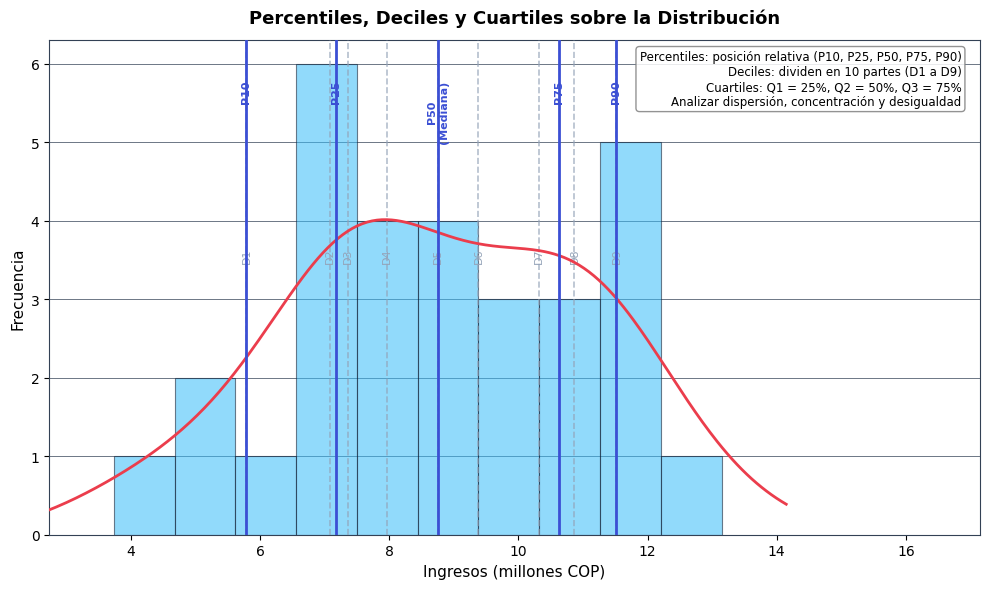

In [ ]:
# Cálculos
percentiles = {f"P{p}": np.percentile(ingresos, p) for p in [10, 25, 50, 75, 90]}
deciles     = {f"D{d}": np.percentile(ingresos, d * 10) for d in range(1, 10)}
cuartiles   = {
    "Q1 (25%)": np.percentile(ingresos, 25),
    "Q2 (50%)": np.percentile(ingresos, 50),
    "Q3 (75%)": np.percentile(ingresos, 75),
    "IQR":      np.percentile(ingresos, 75) - np.percentile(ingresos, 25)
}

print("       PERCENTILES, DECILES Y CUARTILES")
print("")
print(f"  Base (últimos 6 dígitos):  {base}")
print(f"  Tamaño de muestra:         {n}")
print("")
print("  PERCENTILES")
for k, v in percentiles.items():
    print(f"    {k}:   {v:.4f} millones COP")
print("")
print("  DECILES")
for k, v in deciles.items():
    print(f"    {k}:   {v:.4f} millones COP")
print("")
print("  CUARTILES")
for k, v in cuartiles.items():
    print(f"    {k}:  {v:.4f} millones COP")
print(" " * 52)

# Gráfica
COLOR_BAR      = "#38bdf8"
COLOR_PERC     = "#3b4fd4"
COLOR_DEC      = "#94a3b8"
COLOR_MEAN     = "#f97316"

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for spine in ax.spines.values():
    spine.set_edgecolor("#334155")

counts_h, bin_edges_h, _ = ax.hist(
    ingresos, bins=10, color=COLOR_BAR, edgecolor="#0f172a",
    linewidth=0.8, alpha=0.55, zorder=2
)
bin_width = bin_edges_h[1] - bin_edges_h[0]

kde    = stats.gaussian_kde(ingresos)
x_kde  = np.linspace(ingresos.min() - 1, ingresos.max() + 1, 300)
ax.plot(x_kde, kde(x_kde) * n * bin_width, linewidth=2, linestyle="-", zorder=4,color="#EB3D4C")

ymax = ax.get_ylim()[1]

for k, v in deciles.items():
    ax.axvline(v, color=COLOR_DEC, linewidth=1.2, linestyle="--", alpha=0.7, zorder=3)
    ax.text(v, ymax * 0.55, k, rotation=90, fontsize=8,
            color=COLOR_DEC, ha="center", va="bottom")

for k, v in percentiles.items():
    ax.axvline(v, color=COLOR_PERC, linewidth=2, linestyle="-", zorder=5)
    ax.text(v, ymax * 0.92, k if k != "P50" else "P50\n(Mediana)",
            rotation=90, fontsize=8, color=COLOR_PERC,
            ha="center", va="top", fontweight="bold")

textstr = (
    "Percentiles: posición relativa (P10, P25, P50, P75, P90)\n"
    "Deciles: dividen en 10 partes (D1 a D9)\n"
    "Cuartiles: Q1 = 25%, Q2 = 50%, Q3 = 75%\n"
    "Analizar dispersión, concentración y desigualdad"
)
ax.text(0.98, 0.98, textstr, transform=ax.transAxes,
        fontsize=8.5, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
        color="black")

ax.set_title("Percentiles, Deciles y Cuartiles sobre la Distribución",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Ingresos (millones COP)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.grid(axis="y", color="#334155", linewidth=0.5, zorder=1)
ax.set_xlim(ingresos.min() - 1, ingresos.max() + 4)

plt.tight_layout()
plt.show()

<h3><b>Interpretaciones</b></h3>

<h4 style="color:#38bdf8">1. Percentiles</h4>
<ul>
  <li><strong>P50 = 8.75 M:</strong> la mitad de la muestra gana menos de 8.75 millones COP. Coincide con la mediana.</li>
  <li><strong>P90 = 11.52 M:</strong> solo el 10% de las personas supera los 11.52 millones COP, representando los ingresos más altos de la muestra.</li>
</ul>

<h4 style="color:#a78bfa">2. Deciles</h4>
<ul>
  <li><strong>D5 = 8.75 M:</strong> el decil central coincide con la mediana, confirmando la simetría de la distribución.</li>
  <li>La distancia entre deciles consecutivos es relativamente uniforme (entre 0.3 y 0.9 M), lo que indica que los datos están distribuidos de forma pareja sin grandes saltos entre grupos.</li>
</ul>

<h4 style="color:#34d399">3. Cuartiles e IQR</h4>
<ul>
  <li><strong>Q2 = 8.75 M:</strong> el 50% central de la muestra, coincide con la mediana.</li>
  <li><strong>IQR (Diferencia entre Q3 y Q1) = 3.45 M:</strong> el 50% central de los datos se concentra en un rango de 3.45 millones COP (entre 7.17 y 10.62 M). Es una medida robusta de dispersión porque no se ve afectada por valores extremos.</li>
</ul>

<h4 style="color:#f97316">4. Análisis de concentración y desigualdad</h4>
<ul>
  <li>La distancia entre P10 (5.79 M) y P90 (11.52 M) es de 5.73 millones, lo que representa el rango donde se concentra el 80% central de los ingresos.</li>
  <li>El 50% central de los datos (entre Q1 y Q3) varía en un rango de 3.45 millones COP, lo que indica que ese grupo es relativamente homogéneo entre sí.</li>
  Sin embargo, el 25% inferior llega hasta 3.74 M y el 25% superior hasta 13.15 M, por lo que los extremos presentan diferencias salariales considerables respecto al grupo central y entre sí.
  No se puede afirmar que toda la muestra es homogénea: el grupo central (Q1 a Q3) es uniforme, pero los extremos están notablemente más dispersos.
<li>En términos relativos la desigualdad es moderada (el decil más alto gana
aproximadamente el doble que el decil más bajo), aunque en términos absolutos
la diferencia de ~6 millones COP representa un impacto real y significativo
en el nivel de vida de las personas.</li>
</ul>

## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

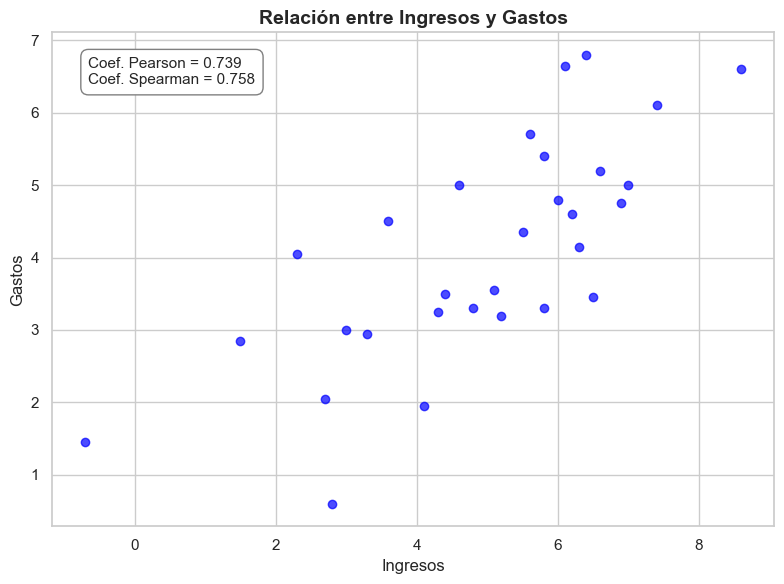

       ANÁLISIS DE CORRELACIÓN

  Base (últimos 6 dígitos):  442407
  Tamaño de muestra:         30 conciertos

  Variable X:  Asistentes al concierto (miles de personas)
  Variable Y:  Streams digitales post-concierto (millones)

  Coef. Pearson:   0.6861  (p-valor: 0.0000)
  Coef. Spearman:  0.6481  (p-valor: 0.0001)
                                                    


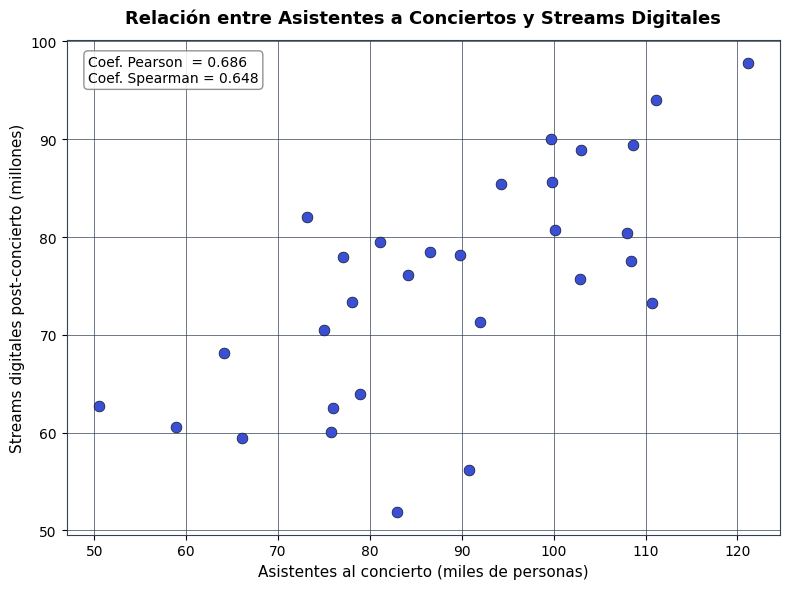

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parámetros
base = 442407
np.random.seed(base)

media_teorica = (base % 10) + 2   # 9
n             = 30

# Asistentes a conciertos (miles de personas)
asistentes = np.random.normal(loc=media_teorica * 10, scale=15, size=n)
asistentes = np.where(asistentes < 0, 0, asistentes)

# Ventas digitales del artista (millones de streams)
# A más asistentes, más streams, pero con ruido
streams = 0.6 * asistentes + np.random.normal(loc=20, scale=10, size=n)
streams = np.where(streams < 0, 0, streams)

# Correlaciones
pearson_r,  pearson_p  = stats.pearsonr(asistentes, streams)
spearman_r, spearman_p = stats.spearmanr(asistentes, streams)

print("       ANÁLISIS DE CORRELACIÓN")
print("")
print(f"  Base (últimos 6 dígitos):  {base}")
print(f"  Tamaño de muestra:         {n} conciertos")
print("")
print(f"  Variable X:  Asistentes al concierto (miles de personas)")
print(f"  Variable Y:  Streams digitales post-concierto (millones)")
print("")
print(f"  Coef. Pearson:   {pearson_r:.4f}  (p-valor: {pearson_p:.4f})")
print(f"  Coef. Spearman:  {spearman_r:.4f}  (p-valor: {spearman_p:.4f})")
print(" " * 52)

# Gráfica
COLOR_DOT  = "#3b4fd4"
COLOR_LINE = "#f97316"

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_edgecolor("#334155")

ax.scatter(asistentes, streams, color=COLOR_DOT, s=60,
           edgecolors="#0f172a", linewidths=0.5, zorder=3)

textstr = f"Coef. Pearson  = {pearson_r:.3f}\nCoef. Spearman = {spearman_r:.3f}"
ax.text(0.03, 0.97, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment="top", horizontalalignment="left",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
        color="black")

ax.set_title("Relación entre Asistentes a Conciertos y Streams Digitales",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Asistentes al concierto (miles de personas)", fontsize=11)
ax.set_ylabel("Streams digitales post-concierto (millones)", fontsize=11)
ax.grid(color="#334155", linewidth=0.5, zorder=1)

plt.tight_layout()
plt.show()

<h3><b>Interpretaciones</b><h3>
<h4>Variables: Asistentes a conciertos vs Streams digitales post-concierto</h4>

<h4 style="color:#38bdf8">1. Correlación de Pearson = 0.686</h4>
<ul>
  <li>Indica una correlación positiva moderada-alta entre los asistentes al concierto y los streams digitales posteriores.</li>
  <li>A medida que aumenta el número de asistentes, tienden a aumentar también los streams, aunque no de forma perfecta.</li>
  <li>El p-valor de 0.0000 indica que esta correlación es estadísticamente significativa: es muy poco probable que se deba al azar.</li>
</ul>

<h4 style="color:#a78bfa">2. Correlación de Spearman = 0.648</h4>
<ul>
  <li>Confirma también una correlación positiva moderada entre las dos variables, pero basada en los rangos de los datos y no en sus valores exactos.</li>
  <li>Es ligeramente menor que Pearson (0.648 vs 0.686), lo que sugiere que la relación es principalmente lineal y no hay una tendencia monótona más fuerte oculta.</li>
  <li>El p-valor de 0.0001 confirma que la correlación es estadísticamente significativa.</li>
  <li>Al ser más robusta frente a valores atípicos, su cercanía con Pearson indica que los datos no tienen outliers que estén distorsionando el resultado.</li>
</ul>

<h4 style="color:#34d399">3. Interpretación conjunta</h4>
<ul>
  <li>Ambos coeficientes apuntan en la misma dirección y tienen magnitudes similares, lo que da solidez a la conclusión: existe una relación positiva real entre asistir a conciertos y el consumo digital del artista.</li>
  <li>Sin embargo, con un coeficiente de ~0.69, la correlación no es perfecta. Factores como el género musical, la plataforma de streaming, la época del año o la popularidad previa del artista también influyen en los streams.</li>
  <li>Visualmente en la gráfica se puede observar la tendencia ascendente general, aunque con bastante dispersión alrededor, lo que es consistente con una correlación moderada y no alta.</li>
</ul>

<h4 style="color:#f97316">4. Fuerza de la correlación</h4>
<ul>
  <li>Usando la escala convencional: valores entre 0.5 y 0.7 se consideran correlación moderada, y entre 0.7 y 0.9 correlación alta.</li>
  <li>Pearson (0.686) está en el límite superior de moderada, casi alcanzando el umbral de alta.</li>
  <li>Esto sugiere que los conciertos son un factor relevante para el impulso de ventas digitales del artista, pero no el único determinante.</li>
</ul>

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

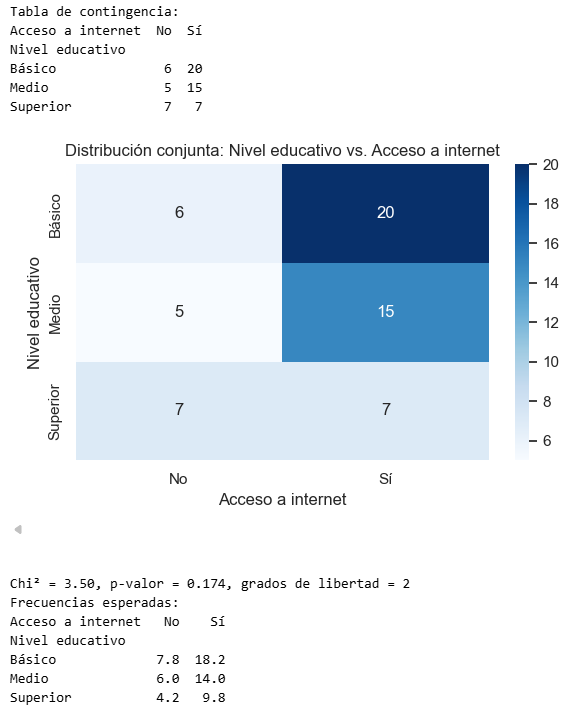

       ANÁLISIS DE ASOCIACIÓN — CHI CUADRADO

  Base (últimos 6 dígitos):  442407
  Tamaño de muestra:         60 películas
  Chi² = 17.9298
  p-valor = 0.0218
  Grados de libertad = 8

  Frecuencias esperadas:
+----------+---------------------------+-----------------+----------------+
|  Género  | Certificada Fresca (≥90%) | Fresca (60-89%) | Podrida (<60%) |
+----------+---------------------------+-----------------+----------------+
|  Acción  |            2.4            |       4.3       |      6.3       |
| Comedia  |            2.2            |       4.0       |      5.8       |
|  Drama   |            3.1            |       5.7       |      8.2       |
| Romance  |            1.5            |       2.7       |      3.9       |
| Thriller |            1.8            |       3.3       |      4.8       |
+----------+---------------------------+-----------------+----------------+



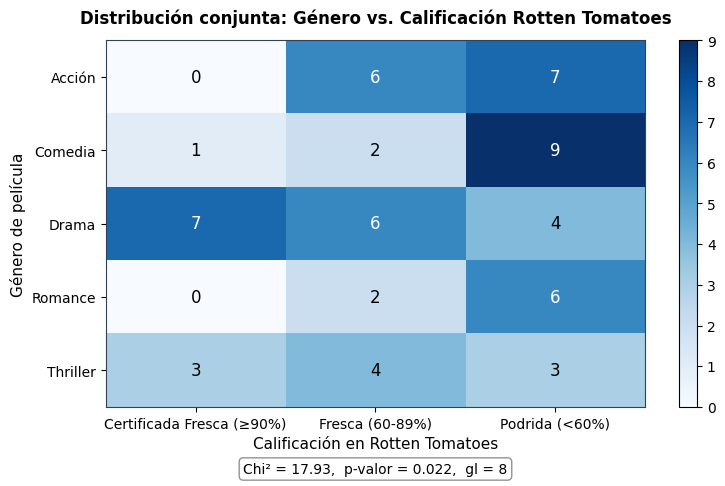

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from tabulate import tabulate

# Parámetros
base = 442407
np.random.seed(base)
n    = 60

# Simulación de variables categóricas
generos = ["Drama", "Acción", "Thriller", "Comedia", "Romance"]
calificaciones = ["Certificada Fresca (≥90%)", "Fresca (60-89%)", "Podrida (<60%)"]

genero_muestra = np.random.choice(generos, size=n, p=[0.25, 0.25, 0.20, 0.20, 0.10])


prob_por_genero = {
    "Drama":    [0.45, 0.35, 0.20],
    "Acción":   [0.20, 0.45, 0.35],
    "Thriller": [0.30, 0.40, 0.30],
    "Comedia":  [0.10, 0.30, 0.60],
    "Romance":  [0.15, 0.40, 0.45]
}

calif_muestra = np.array([
    np.random.choice(calificaciones, p=prob_por_genero[g])
    for g in genero_muestra
])

# DataFrame y tabla de contingencia
df      = pd.DataFrame({"Género": genero_muestra, "Calificación RT": calif_muestra})
tabla   = pd.crosstab(df["Género"], df["Calificación RT"])
tabla = tabla[calificaciones]

print("       ANÁLISIS DE ASOCIACIÓN — CHI CUADRADO")
print("")
print(f"  Base (últimos 6 dígitos):  {base}")
print(f"  Tamaño de muestra:         {n} películas")

# Chi cuadrado
chi2, p_valor, gl, frec_esperadas = chi2_contingency(tabla)

print(f"  Chi² = {chi2:.4f}")
print(f"  p-valor = {p_valor:.4f}")
print(f"  Grados de libertad = {gl}")
print("")
print("  Frecuencias esperadas:")
fe_df = pd.DataFrame(frec_esperadas.round(1),
                     index=tabla.index,
                     columns=tabla.columns)
fe_df.index.name= "Género"
print(tabulate(fe_df, headers="keys", tablefmt="pretty", floatfmt=".1f"))
print("")

# Gráfica — mapa de calor
fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values():
    spine.set_edgecolor("#334155")

data   = tabla.values
im     = ax.imshow(data, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(tabla.columns)))
ax.set_xticklabels(tabla.columns, fontsize=10)
ax.set_yticks(range(len(tabla.index)))
ax.set_yticklabels(tabla.index, fontsize=10)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, str(data[i, j]),
                ha="center", va="center", fontsize=12,
                color="white" if data[i, j] > data.max() * 0.6 else "black")

plt.colorbar(im, ax=ax)
ax.set_title("Distribución conjunta: Género vs. Calificación Rotten Tomatoes",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Calificación en Rotten Tomatoes", fontsize=11)
ax.set_ylabel("Género de película", fontsize=11)

textstr = f"Chi² = {chi2:.2f},  p-valor = {p_valor:.3f},  gl = {gl}"
ax.text(0.50, -0.18, textstr, transform=ax.transAxes,
        fontsize=10, ha="center",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
        color="black")

plt.tight_layout()
plt.show()

<h3><b>Interpretaciones</b></h3>
<h4>Variables: Género de película vs. Calificación en Rotten Tomatoes</h4>

<h4 style="color:#38bdf8">1. Tabla de contingencia</h4>
<ul>
  <li>Drama es el género con más películas Certificadas Frescas (7), lo que sugiere que tiende a recibir mejor recepción crítica.</li>
  <li>Comedia concentra la mayor cantidad de películas Podridas (9 de 12), confirmando la tendencia de este género a recibir calificaciones bajas en RT.</li>
  <li>Acción no obtuvo ninguna Certificada Fresca, con la mayoría de sus películas cayendo en Fresca o Podrida.</li>
  <li>Romance tampoco obtuvo Certificadas Frescas, con 6 de 8 películas clasificadas como Podridas.</li>
  <li>Thriller muestra la distribución más equilibrada entre las tres categorías (3, 4, 3).</li>
</ul>

<h4 style="color:#a78bfa">2. Frecuencias esperadas</h4>
<ul>
  <li>Las frecuencias esperadas representan los valores que se observarían si el género no tuviera ninguna influencia sobre la calificación.</li>
  <li>Al comparar observadas vs esperadas, Drama supera ampliamente lo esperado en Certificada Fresca (7 vs 3.1), indicando que este género tiene una asociación real con las mejores calificaciones.</li>
  <li>Comedia observó 9 Podridas frente a las 5.8 esperadas, reforzando que su mala recepción crítica no es aleatoria.</li>
</ul>

<h4 style="color:#34d399">3. Prueba Chi Cuadrado</h4>
<ul>
  <li>Chi² = 17.93 con 8 grados de libertad.</li>
  <li>El p-valor de 0.022 es menor que el nivel de significancia convencional de 0.05.</li>
  <li>Esto significa que se rechaza la hipótesis nula de independencia: el género de la película y su calificación en Rotten Tomatoes no son variables independientes.</li>
  <li>Dicho de forma simple el género sí influye en la calificación que recibe una película.</li>
</ul>

### <span style="color:#2F749F;"><strong>Ejercicio 7: PCA</strong></span>

El conjunto de datos utilizado corresponde al listado de **los 100 mejores actores de Hollywood de todos los tiempos según IMDb**, disponible en Kaggle. Contiene información sobre 100 actores distribuida en las siguientes variables:

* **Name:** nombre completo del actor.
* **Date of Birth:** fecha de nacimiento del actor.
* **Place of Birth:** ciudad y país de nacimiento del actor.
* **Oscars:** número de premios Oscar ganados.
* **Oscar Nominations: **número de veces que el actor fue nominado al Oscar.
* **BAFTA:** número de premios BAFTA ganados.
* **BAFTA Nominations: **número de veces que el actor fue nominado al BAFTA.
* **Golden Globes: **número de premios Golden Globe ganados.
* **Golden Globe Nominations: **número de veces que el actor fue nominado al Golden Globe.
* **Greatest Performances:** listado de las actuaciones más reconocidas del actor.

Para el desarrollo del análisis de componentes principales se trabajó únicamente con las **variables numéricas**, es decir, Oscars, Oscar Nominations, BAFTA, BAFTA Nominations, Golden Globes y Golden Globe Nominations, dado que el PCA requiere datos cuantitativos para su aplicación.






**Cargar base de datos**

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd

base_datos = pd.read_csv('/content/drive/MyDrive/Datos/Top 100 Greatest Hollywood Actors of All Time.csv')


,Name,Date of Birth,Place of Birth,Oscars,Oscar Nominations,BAFTA,BAFTA Nominations,Golden Globes,Golden Globe Nominations,Greatest Performances
0,Al Pacino,25 April 1940,"East Harlem, New York, United States",1,8,2,5,4,15,"Serpico, Scent of a Woman, Dog Day Afternoon, ..."
1,Alan Arkin,26 March 1934,"Brooklyn, New York, United States",1,4,1,3,1,6,"Argo, Little Miss Sunshine, The Heart Is a Lon..."
2,Alan Rickman,21 February 1946,"Hammersmith, London, United Kingdom",0,0,1,4,1,1,"Michael Collins, Truly Madly Deeply, Sense and..."
3,Albert Finney,9 May 1936,"Charlestown, Salford, United Kingdom",0,5,2,13,2,9,"The Murder on the orient Express, The Dresser,..."
4,Alec Guinness,2 April 1914,"Maida Vale, London, United Kingdom",1,5,3,7,1,3,"Star Wars, Little Dorrit, The Bridge on the Ri..."


**Análisis de PCA**

            Name     Date of Birth                        Place of Birth  \
0      Al Pacino     25 April 1940  East Harlem, New York, United States   
1     Alan Arkin     26 March 1934     Brooklyn, New York, United States   
2   Alan Rickman  21 February 1946   Hammersmith, London, United Kingdom   
3  Albert Finney        9 May 1936  Charlestown, Salford, United Kingdom   
4  Alec Guinness      2 April 1914    Maida Vale, London, United Kingdom   

   Oscars  Oscar Nominations  BAFTA  BAFTA Nominations  Golden Globes  \
0       1                  8      2                  5              4   
1       1                  4      1                  3              1   
2       0                  0      1                  4              1   
3       0                  5      2                 13              2   
4       1                  5      3                  7              1   

   Golden Globe Nominations                              Greatest Performances  
0                      

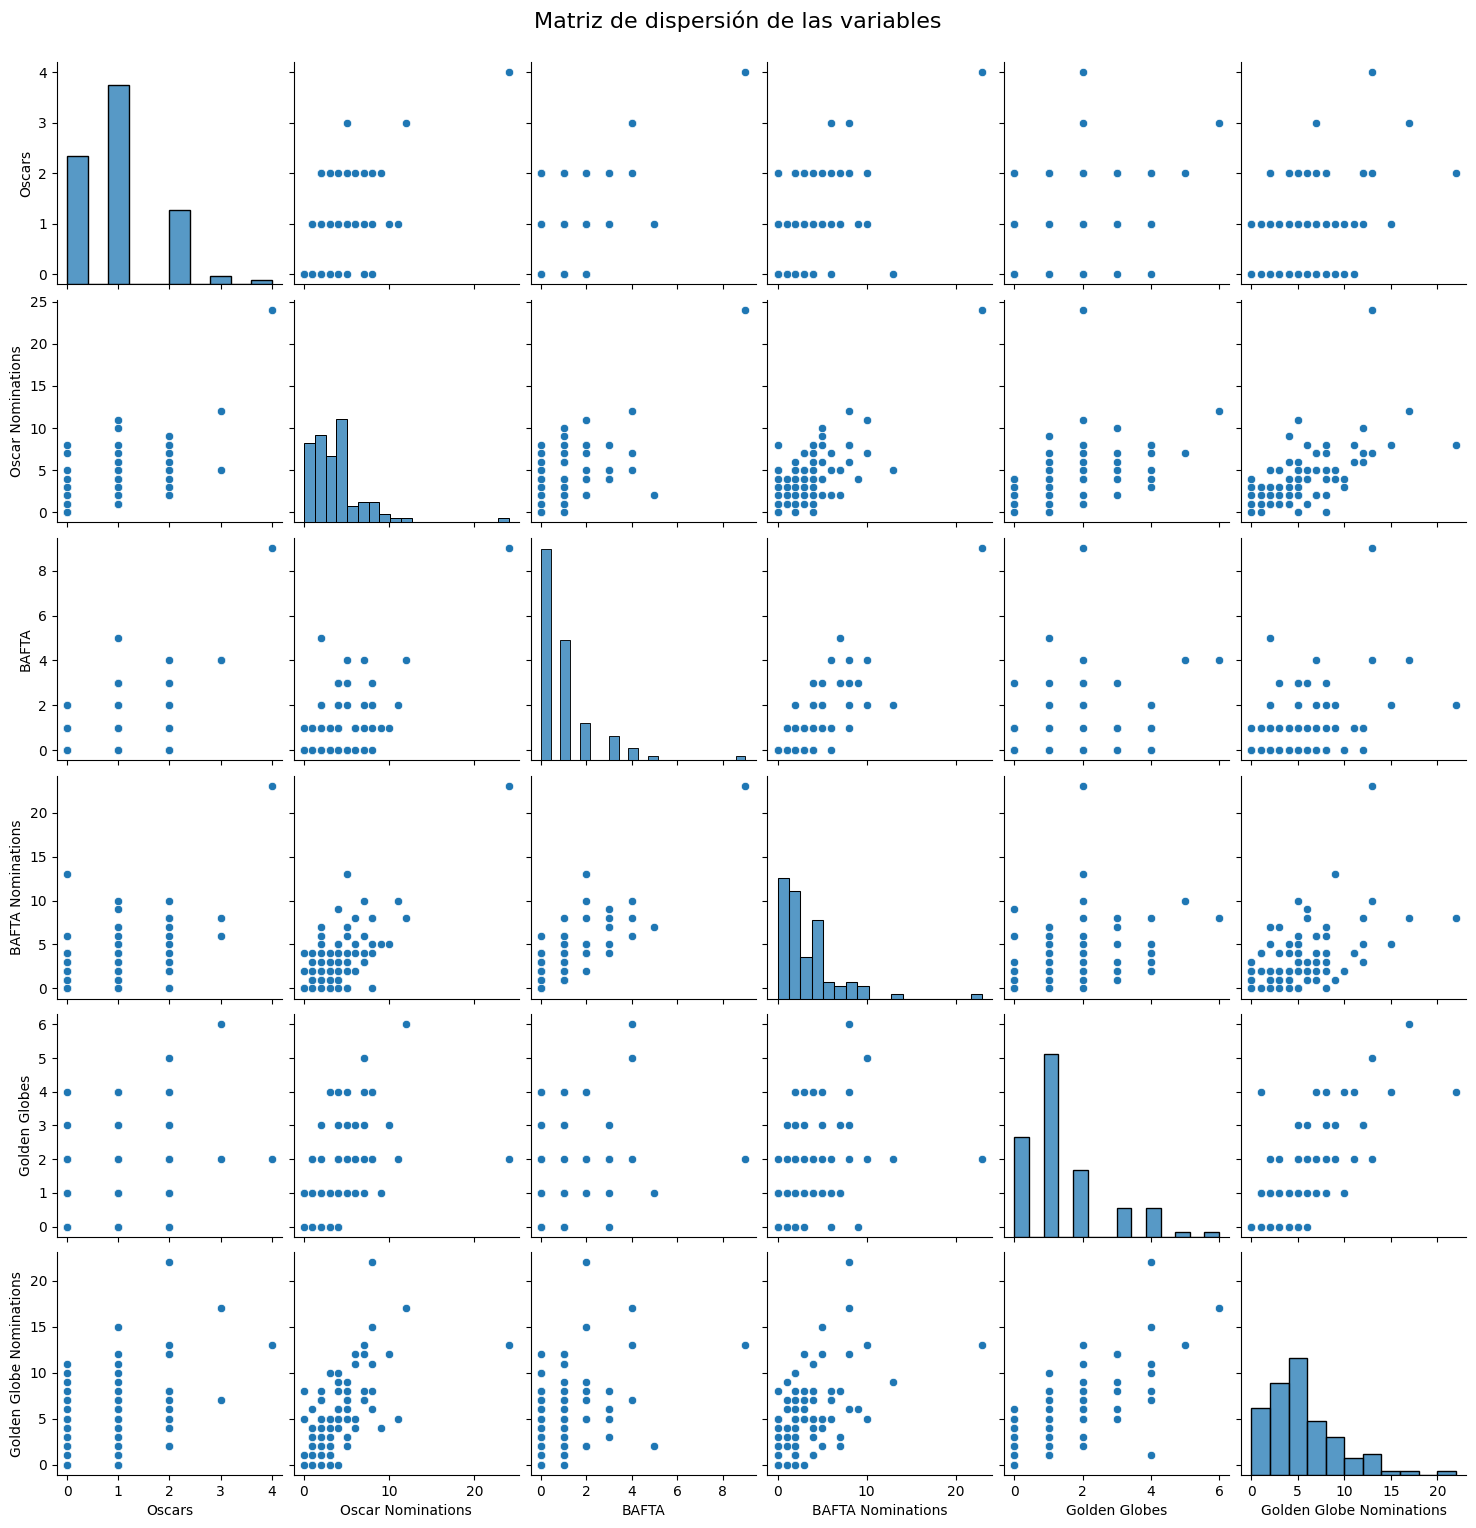

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Tu base de datos ya cargada
df = base_datos.copy()

# Ver primeras filas
print(df.head())

# Seleccionar solo columnas numéricas
X = df.select_dtypes(include=[np.number])

# Estandarizar variables
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Pairplot (matriz de dispersión)
sns.pairplot(df, diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión de las variables', fontsize=16, y=1.02)
plt.show()

**INTERPRETACIÓN**

En la matriz de dispersión se pueden ver las relaciones entre las variables de premios de los actores. Se observa una relación positiva entre varias de ellas: cuando un actor tiene muchas nominaciones al Oscar, es probable que también tenga muchas nominaciones al BAFTA o al Golden Globe, lo que sugiere que el reconocimiento en una premiación suele ir acompañado de reconocimiento en las demás. También se nota que la mayoría de los actores se concentran en valores bajos de premios y nominaciones, mientras que solo algunos casos destacan con números significativamente más altos. Dado que las variables muestran correlaciones entre sí, se considera apropiado aplicar PCA, ya que permite resumir esta información en menos dimensiones sin perder lo más relevante

**Paso 1**

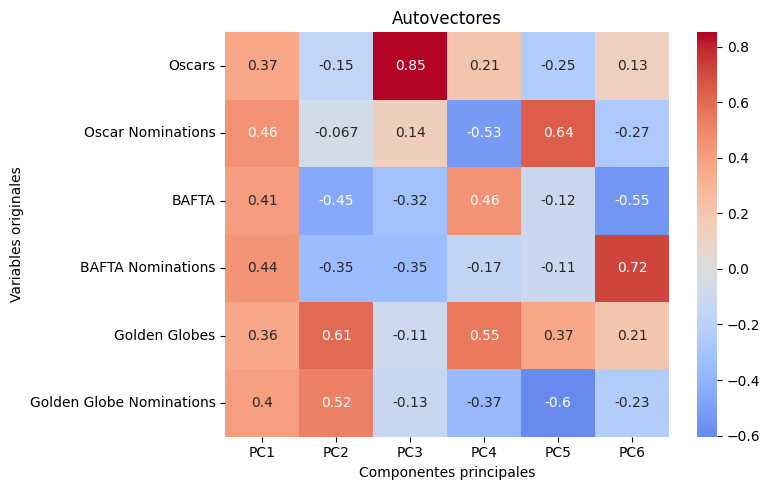

Ecuaciones de los componentes principales:

PC1 = 0.366·'Oscars' + 0.458·'Oscar Nominations' + 0.41·'BAFTA' + 0.443·'BAFTA Nominations' + 0.363·'Golden Globes' + 0.399·'Golden Globe Nominations'
PC2 = -0.151·'Oscars' + -0.067·'Oscar Nominations' + -0.455·'BAFTA' + -0.352·'BAFTA Nominations' + 0.611·'Golden Globes' + 0.518·'Golden Globe Nominations'
PC3 = 0.851·'Oscars' + 0.145·'Oscar Nominations' + -0.321·'BAFTA' + -0.352·'BAFTA Nominations' + -0.107·'Golden Globes' + -0.129·'Golden Globe Nominations'
PC4 = 0.207·'Oscars' + -0.53·'Oscar Nominations' + 0.457·'BAFTA' + -0.165·'BAFTA Nominations' + 0.551·'Golden Globes' + -0.37·'Golden Globe Nominations'
PC5 = -0.245·'Oscars' + 0.642·'Oscar Nominations' + -0.119·'BAFTA' + -0.111·'BAFTA Nominations' + 0.37·'Golden Globes' + -0.604·'Golden Globe Nominations'
PC6 = 0.127·'Oscars' + -0.267·'Oscar Nominations' + -0.547·'BAFTA' + 0.718·'BAFTA Nominations' + 0.207·'Golden Globes' + -0.233·'Golden Globe Nominations'


In [14]:
# Matriz de componentes
componentes = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X.columns))],
    index=X.columns
)

# Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# Ecuaciones de los componentes principales con nombres reales
print("Ecuaciones de los componentes principales:\n")

for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join(
        [f"{round(pesos[j],3)}·'{X.columns[j]}'" for j in range(len(pesos))]
    )
    print(f"{comp} = {ecuacion}")

**INTERPRETACIÓN**
* **PC1** tiene todos los valores en rojo y similares entre sí, lo que indica que resume el éxito general de un actor en todos los premios por igual. Un actor con PC1 alto simplemente ganó y fue nominado en todo.

* **PC2** muestra un contraste claro; Golden Globes y sus nominaciones están en rojo (0.61 y 0.52) mientras que BAFTA está en azul (-0.45). Esto muestra una clara separacion entre los actores que brillaron en los Golden Globes de los que lo hicieron en los BAFTA.

* **PC3** tiene un rojo muy intenso solo en Oscars (0.85), mientras el resto es azul o casi cero. Esto captura actores que ganaron Oscars de forma destacada respecto a sus otros premios, es decir, actores cuyo fuerte particular fueron los Oscars, dejando a un lado a los demás premios.

* **PC4**, **PC5** y **PC6** ya son más difíciles de interpretar y explican menos varianza, por ende no valen la pena ser analizados.

**Paso 2**

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      3.712  0.612          0.612
1        PC2      0.977  0.161          0.774
2        PC3      0.633  0.104          0.878
3        PC4      0.357  0.059          0.937
4        PC5      0.249  0.041          0.978
5        PC6      0.132  0.022          1.000


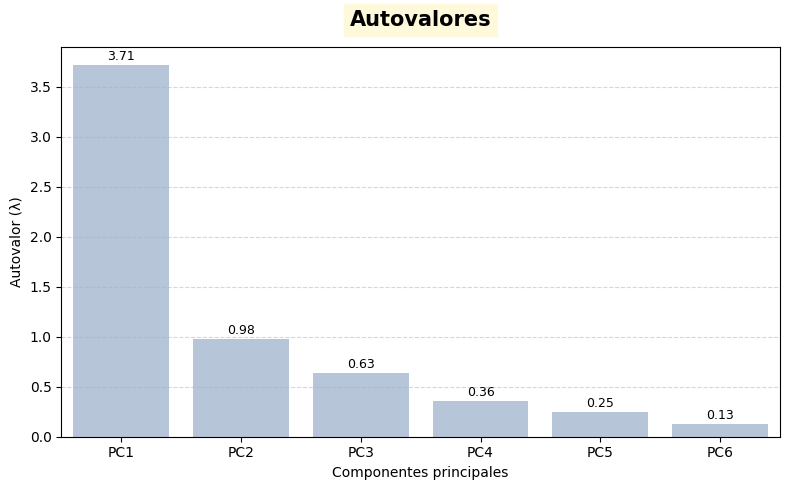

In [15]:
# Varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes_nombres = [f'PC{i+1}' for i in range(len(PVE))]

# DataFrame resumen
df_varianza = pd.DataFrame({
    'Componente': componentes_nombres,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

# Gráfico: Autovalores
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
for i, v in enumerate(df_varianza['Autovalor']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.title("Autovalores", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

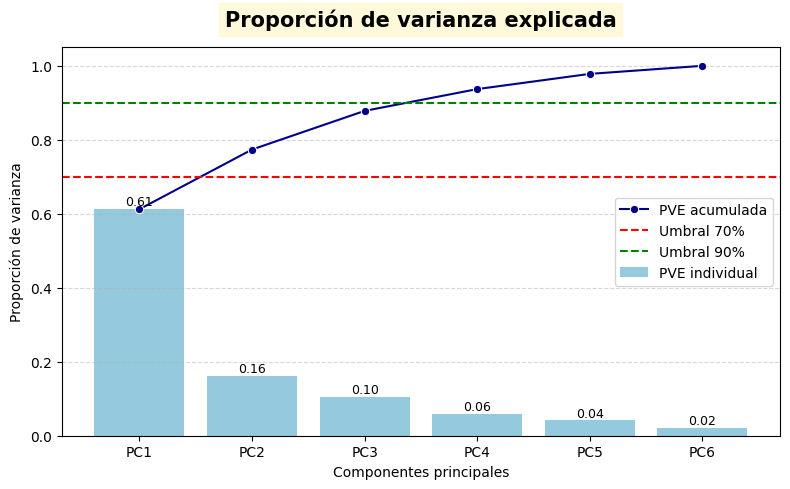

In [16]:
# Gráfico 2: Proporción de varianza explicada
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='PVE', data=df_varianza, color='skyblue', label='PVE individual')
sns.lineplot(x='Componente', y='PVE acumulada', data=df_varianza, marker='o', color='darkblue', label='PVE acumulada')

plt.axhline(0.7, color='red', linestyle='--', label='Umbral 70%')
plt.axhline(0.9, color='green', linestyle='--', label='Umbral 90%')

for i, v in enumerate(df_varianza['PVE']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=9, color='black')

plt.title("Proporción de varianza explicada", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Proporción de varianza")
plt.xlabel("Componentes principales")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**INTERPRETACIÓN**
* En el **gráfico de autovalores** se observa que PC1 destaca ampliamente sobre las demás componentes, con un valor de 3.71, lo que refleja que concentra la mayor parte de la información del conjunto de datos. A medida que se avanza hacia PC2 y PC3, los autovalores disminuyen considerablemente, y las componentes restantes aportan cada vez menos.

* En la **tabla de autovalores**, PC1 por sí sola representa el 61.2% de la varianza total. Al incorporar PC2 y PC3, la varianza acumulada asciende al 87.8%, lo que significa que estas tres componentes logran capturar casi el 88% de la información original contenida en las seis variables. Siguiendo el criterio propuesto por Jolliffe & Cadima (2016), que recomienda retener los componentes que expliquen entre el 70% y el 90% de la varianza total, se decide trabajar con PC1, PC2 y PC3, ya que permiten reducir la dimensionalidad del problema de forma significativa sin perder una parte relevante de la información.

* Por otro lado, en **la tabla de proporcion de varianza explicada**,  se puede notar cómo después de PC3 la curva acumulada disminuye su pendiente considerablemente, lo cual refuerza la decisión de trabajar con PC1, PC2 y PC3.

**Paso 3**

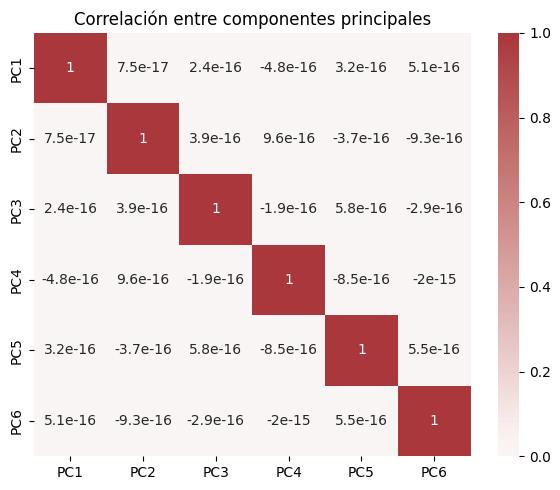

In [17]:
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(PVE))])
correlaciones = df_pca.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones, annot=True, cmap='vlag', center=0)
plt.title('Correlación entre componentes principales')
plt.tight_layout()
plt.show()

**INTERPRETACIÓN**

Se confirma la ortogonalidad del PCA, evidenciando que cada PC  está completamente incorrelacionada con las demás, lo cual es un resultado esperado y deseable del método.

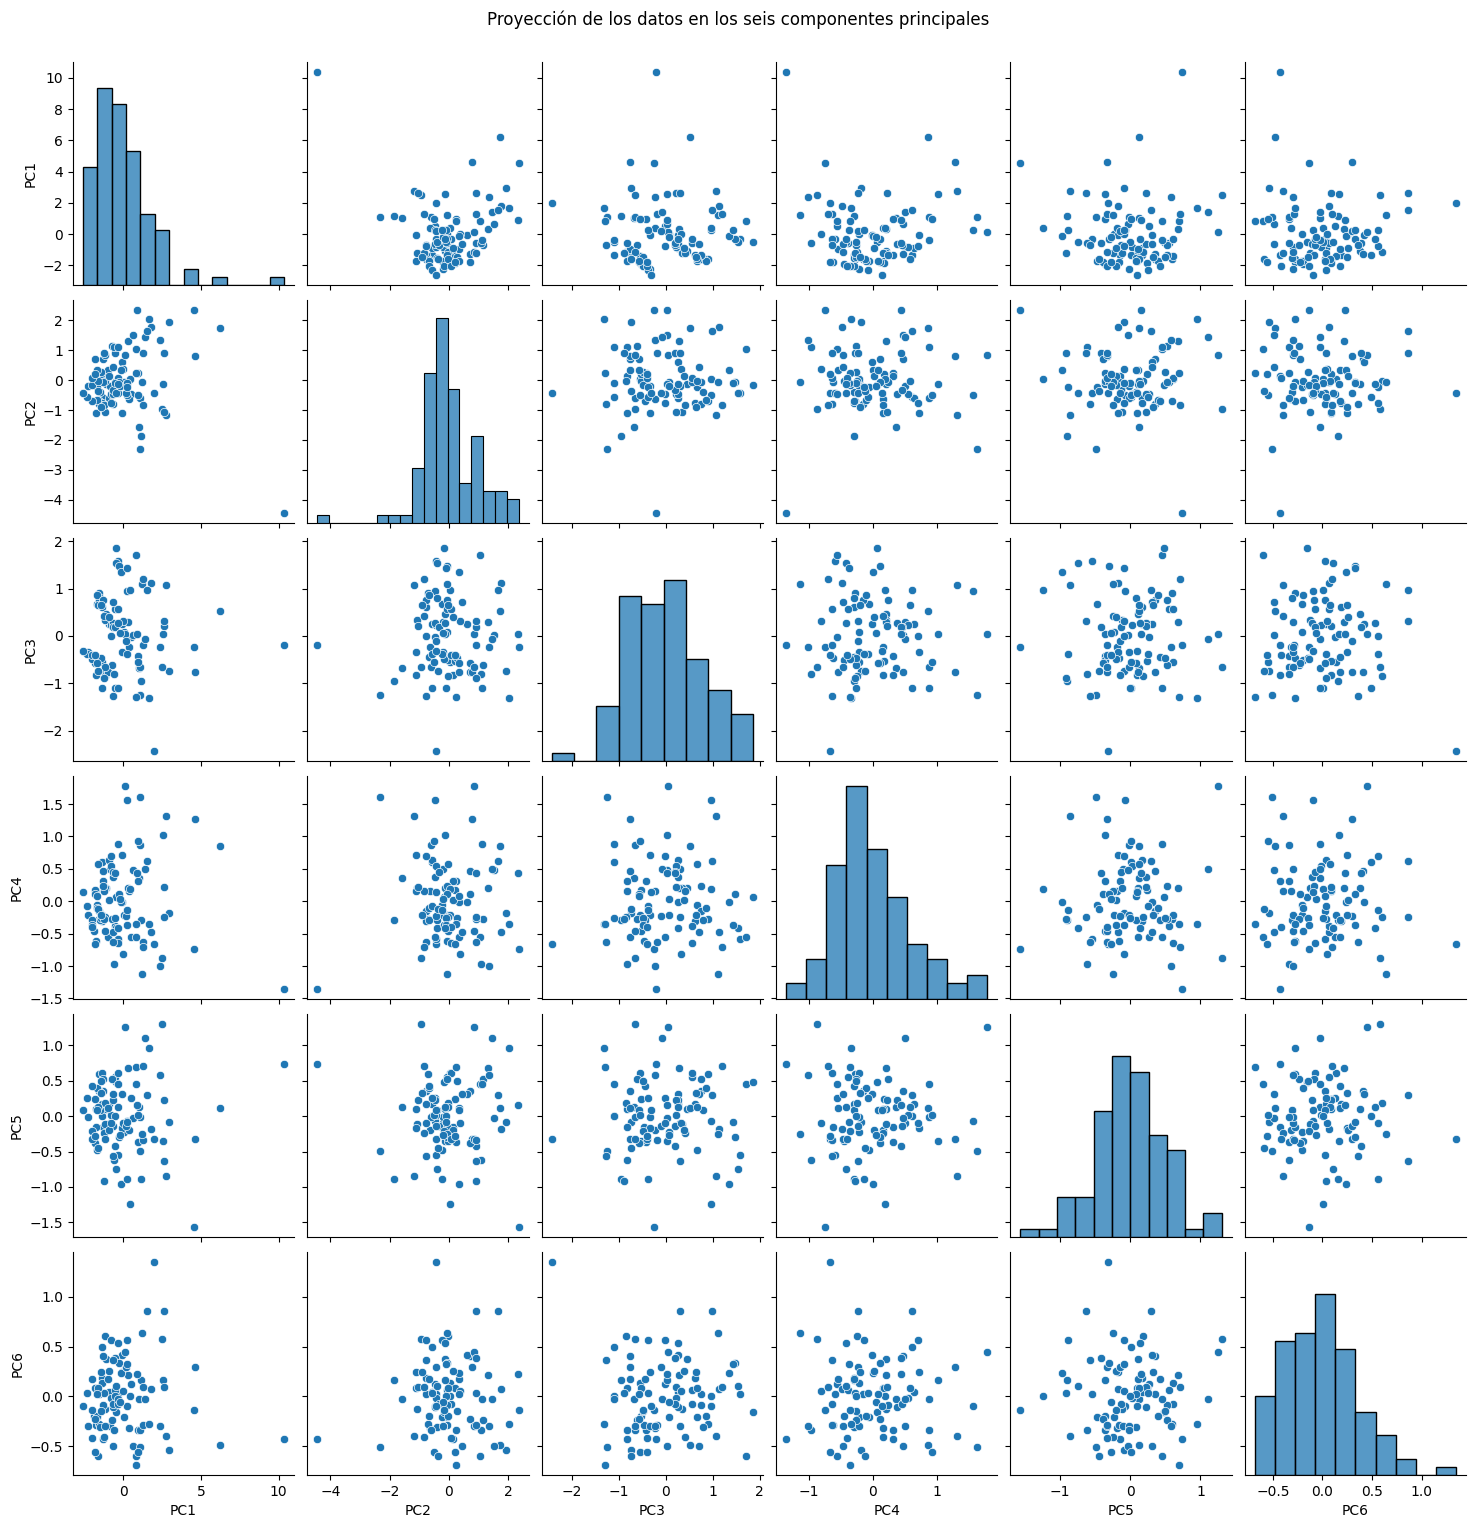

In [20]:
sns.pairplot(df_pca[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']])
plt.suptitle('Proyección de los datos en los seis componentes principales', y=1.02)
plt.show()

**INTERPRETACIÓN**

En este último gráfico se evidencia cómo en todos los scatter los puntos están dispersos sin ningún patrón claro, lo que visualmente confirma lo mismo que mostró la matriz de correlación: las componentes son independientes entre sí, es decir, ninguna PC predice a otra.